# インド株 ファクター検証 — Step 9: CGO の遡及期間比較（12ヶ月 / 13ヶ月 / 2年 / 3年 / 5年）

## 動機: インドのキャピタルゲイン税制

上場株式の課税は**保有12ヶ月**を境に短期（STCG）/長期（LTCG）に分かれる:

| | 〜2024年6月 | 2024年7月〜 |
|---|---|---|
| 短期（保有 ≤ 12ヶ月, STT対象） | 15% | **20%** |
| 長期（保有 > 12ヶ月） | 10% | **12.5%** |

処分効果（含み益の売り急ぎ）が課税で歪むなら、**「12ヶ月の壁」の前後で
含み益の売り圧力が変わる**はず（短期の含み益は税率が高いので売却が先送りされ、
壁を越えた直後に売却が出やすい等）。遡及期間 $N$ を変えた CGO は
「どの保有年限の株主の含み損益か」の近似になる:

- $N$ = 12ヶ月（252営業日）: **ほぼ全員が STCG 圏**の取得価格ベース
- $N$ = 13ヶ月（273営業日）: 壁を越えた直後までを含む
- $N$ = 2〜5年: LTCG 圏の株主を含む長期ベース（原論文は 5 年）

## 規約

- **日次ベース**（1ヶ月 = 21営業日、1期ラグ = 前営業日）。
  事前計算済みの `data/cgo/`（`scripts/build_cgo.py`、Step 11 と同一）を読む
- `min_periods = N`（**フル・ルックバックが確保できる時点から出力**。
  ホライズン間で定義を一貫させるため）
- 共通評価期間 **200801〜202607**（最長の 5 年版が出力可能になる時点に揃える）
- 他は Step 8 と同一（PIT・Blom・EW）

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import sys, time
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import factorlab as fl

fl.plotting.set_style()
pd.set_option("display.width", 250, "display.max_columns", 40, "display.float_format", lambda v: f"{v:,.3f}")

START, END = 200801, 202607
Q = 5
WEIGHTING = "ew"
FIGDIR = "09_cgo_horizon"

# data/cgo の列名（日次ベース、1ヶ月 = 21営業日）
HORIZONS = ["cgo_12m", "cgo_13m", "cgo_24m", "cgo_36m", "cgo_60m"]
HLABELS = {"cgo_12m": "12 months (252d)", "cgo_13m": "13 months (273d)",
           "cgo_24m": "2 years (504d)", "cgo_36m": "3 years (756d)", "cgo_60m": "5 years (1260d)"}

## 1. 事前計算済みスコアの読み込み（`data/cgo/`）

In [2]:
t0 = time.time()
cgo_multi = fl.cgo.load_cgo_monthly(HORIZONS, start=START, end=END)
print(f"{time.time()-t0:.2f} 秒  shape={cgo_multi.shape}")
cgo_multi.describe().T[["count", "mean", "std", "25%", "50%", "75%"]]

0.17 秒  shape=(170405, 5)


,count,mean,std,25%,50%,75%
cgo_12m,"165,261.000",-0.100,0.770,-0.174,-0.008,0.122
cgo_13m,"164,807.000",-0.109,0.851,-0.181,-0.007,0.128
cgo_24m,"159,652.000",-0.192,1.720,-0.228,0.004,0.167
cgo_36m,"153,870.000",-0.271,2.447,-0.247,0.017,0.196
cgo_60m,"142,248.000",-0.393,4.216,-0.250,0.042,0.239


In [3]:
panel = fl.data.build_panel(["mom12_1"], start=START, end=END)
for c in HORIZONS:
    panel[c] = cgo_multi[c].reindex(panel.index)
panel = fl.preprocess.standardize_panel(panel, list(HORIZONS) + ["mom12_1"], method="blom")
fl.altdata.score_characteristics(panel, list(HORIZONS))[
    ["n_stocks_mean", "coverage_univ", "coverage_bench", "rank_autocorr"]]

,n_stocks_mean,coverage_univ,coverage_bench,rank_autocorr
cgo_12m,368.677,0.983,0.996,0.844
cgo_13m,367.807,0.981,0.996,0.854
cgo_24m,356.830,0.955,0.986,0.906
cgo_36m,343.439,0.921,0.966,0.925
cgo_60m,317.484,0.854,0.919,0.941


## 2. ホライズン間の相関（+ mom12_1）

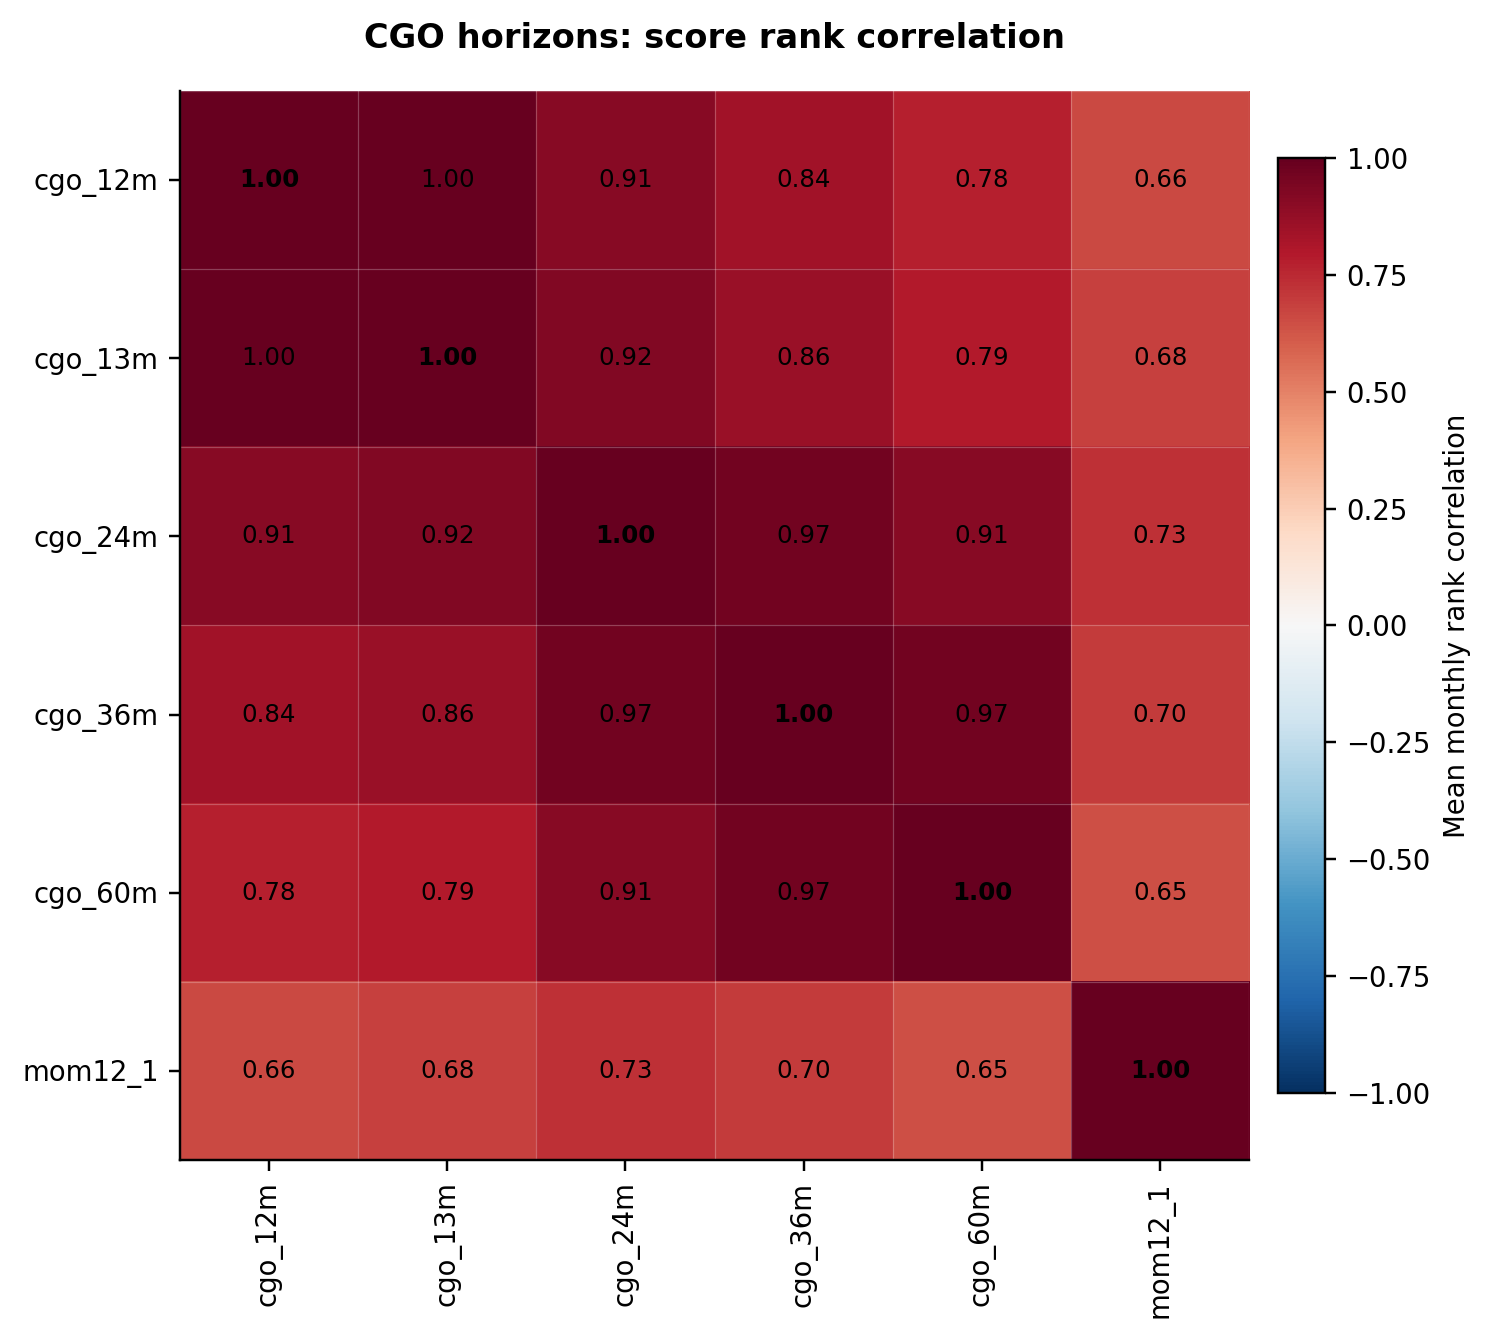

In [4]:
cols = [f"{c}_blom" for c in HORIZONS] + ["mom12_1_blom"]
labs = list(HORIZONS) + ["mom12_1"]
corr = fl.multi.cross_sectional_corr(panel, cols, labels=labs)
fig = fl.plotting.plot_factor_matrix(
    corr, title="CGO horizons: score rank correlation",
    off_label="Mean monthly rank correlation",
    off_vmin=-1, off_vmax=1, annotate=True, figsize=(7.6, 6.2), band=0.0)
fl.plotting.savefig(fig, f"{FIGDIR}/70_horizon_corr");

## 3. 分位分析 — raw

In [5]:
res_raw, sum_raw = {}, {}
for c in HORIZONS:
    res_raw[c] = fl.quantile.quantile_returns(panel, f"{c}_blom", q=Q, ascending=True)
    sum_raw[c] = fl.quantile.quantile_summary(res_raw[c], weighting=WEIGHTING)

spread = f"Q{Q}-Q1"
pd.concat({HLABELS[c]: sum_raw[c].loc[[f"Q{Q}", spread],
    ["ann_excess", "te", "IR", "t_stat_NW", "max_dd_excess", "turnover_ann"]]
    for c in HORIZONS}, names=["horizon", "bucket"])

ann_excess    te    IR  t_stat_NW  max_dd_excess  turnover_ann
horizon          bucket                                                                
12 months (252d) Q5           0.071 0.109 0.569      2.942         -0.188         3.886
                 Q5-Q1        0.102 0.215 0.569      2.589         -0.569         7.935
13 months (273d) Q5           0.072 0.109 0.572      2.955         -0.187         3.767
                 Q5-Q1        0.105 0.219 0.575      2.658         -0.572         7.689
2 years (504d)   Q5           0.077 0.109 0.613      3.035         -0.144         3.060
                 Q5-Q1        0.093 0.223 0.519      2.266         -0.589         6.358
3 years (756d)   Q5           0.072 0.109 0.562      2.727         -0.211         2.703
                 Q5-Q1        0.076 0.225 0.448      1.959         -0.584         5.756
5 years (1260d)  Q5           0.080 0.108 0.627      3.035         -0.196         2.303
                 Q5-Q1        0.081 0.221 0.470      2.111         -0.578         5.146

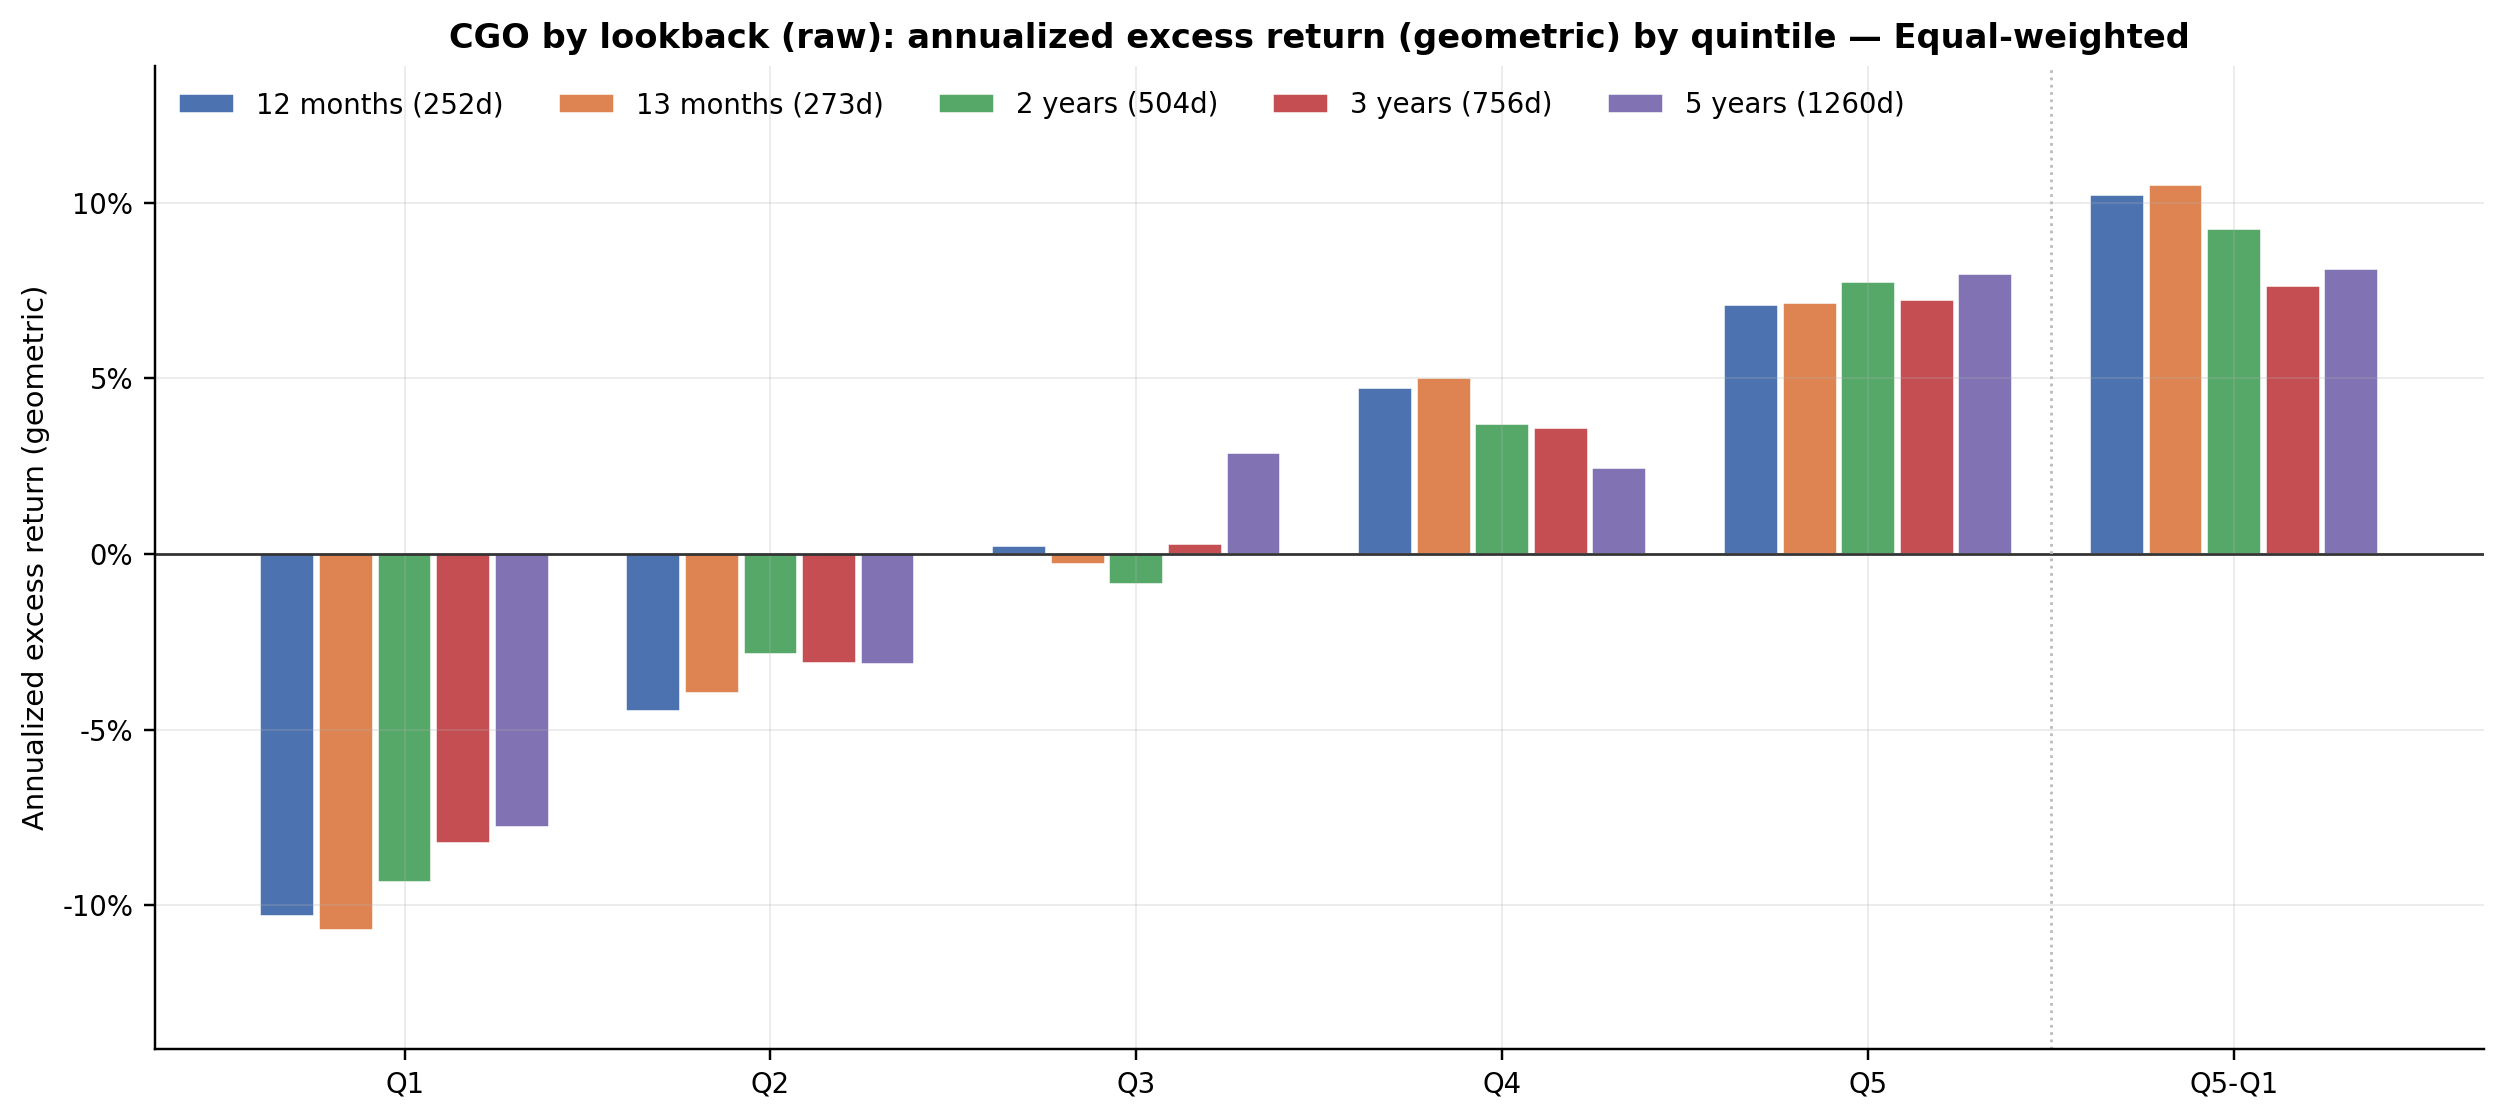

In [6]:
fig = fl.plotting.plot_variant_quantile_bar(sum_raw, q=Q, factor="CGO by lookback (raw)",
                                            weighting=WEIGHTING, labels=HLABELS)
fl.plotting.savefig(fig, f"{FIGDIR}/71_quantile_bar_raw");

## 4. 分位分析 — momentum 中立（size + sector + mom12_1 を同時コントロール）

CGO とモメンタムの重なりはホライズンが短いほど強いはず。
中立化後に**どのホライズンの増分情報が残るか**が本題。

In [7]:
for c in HORIZONS:
    panel = fl.preprocess.standardize_panel(
        panel, c, method="blom", group_col="sector",
        control_cols=["log_cap", "mom12_1_blom"], suffix="_blom_mn")

res_mn, sum_mn = {}, {}
for c in HORIZONS:
    res_mn[c] = fl.quantile.quantile_returns(panel, f"{c}_blom_mn", q=Q, ascending=True)
    sum_mn[c] = fl.quantile.quantile_summary(res_mn[c], weighting=WEIGHTING)

pd.concat({HLABELS[c]: sum_mn[c].loc[[f"Q{Q}", spread],
    ["ann_excess", "te", "IR", "t_stat_NW", "max_dd_excess", "turnover_ann"]]
    for c in HORIZONS}, names=["horizon", "bucket"])

ann_excess    te    IR  t_stat_NW  max_dd_excess  turnover_ann
horizon          bucket                                                                
12 months (252d) Q5           0.001 0.112 0.075      0.352         -0.355         5.938
                 Q5-Q1        0.014 0.131 0.169      0.812         -0.391        11.918
13 months (273d) Q5           0.006 0.112 0.117      0.520         -0.346         5.956
                 Q5-Q1        0.023 0.130 0.240      1.136         -0.360        11.998
2 years (504d)   Q5           0.017 0.105 0.219      0.949         -0.337         5.403
                 Q5-Q1        0.018 0.126 0.204      0.878         -0.425        11.183
3 years (756d)   Q5           0.013 0.099 0.178      0.760         -0.308         4.654
                 Q5-Q1        0.012 0.126 0.156      0.657         -0.380         9.815
5 years (1260d)  Q5           0.031 0.102 0.318      1.343         -0.255         3.852
                 Q5-Q1        0.032 0.131 0.309      1.312         -0.310         8.490

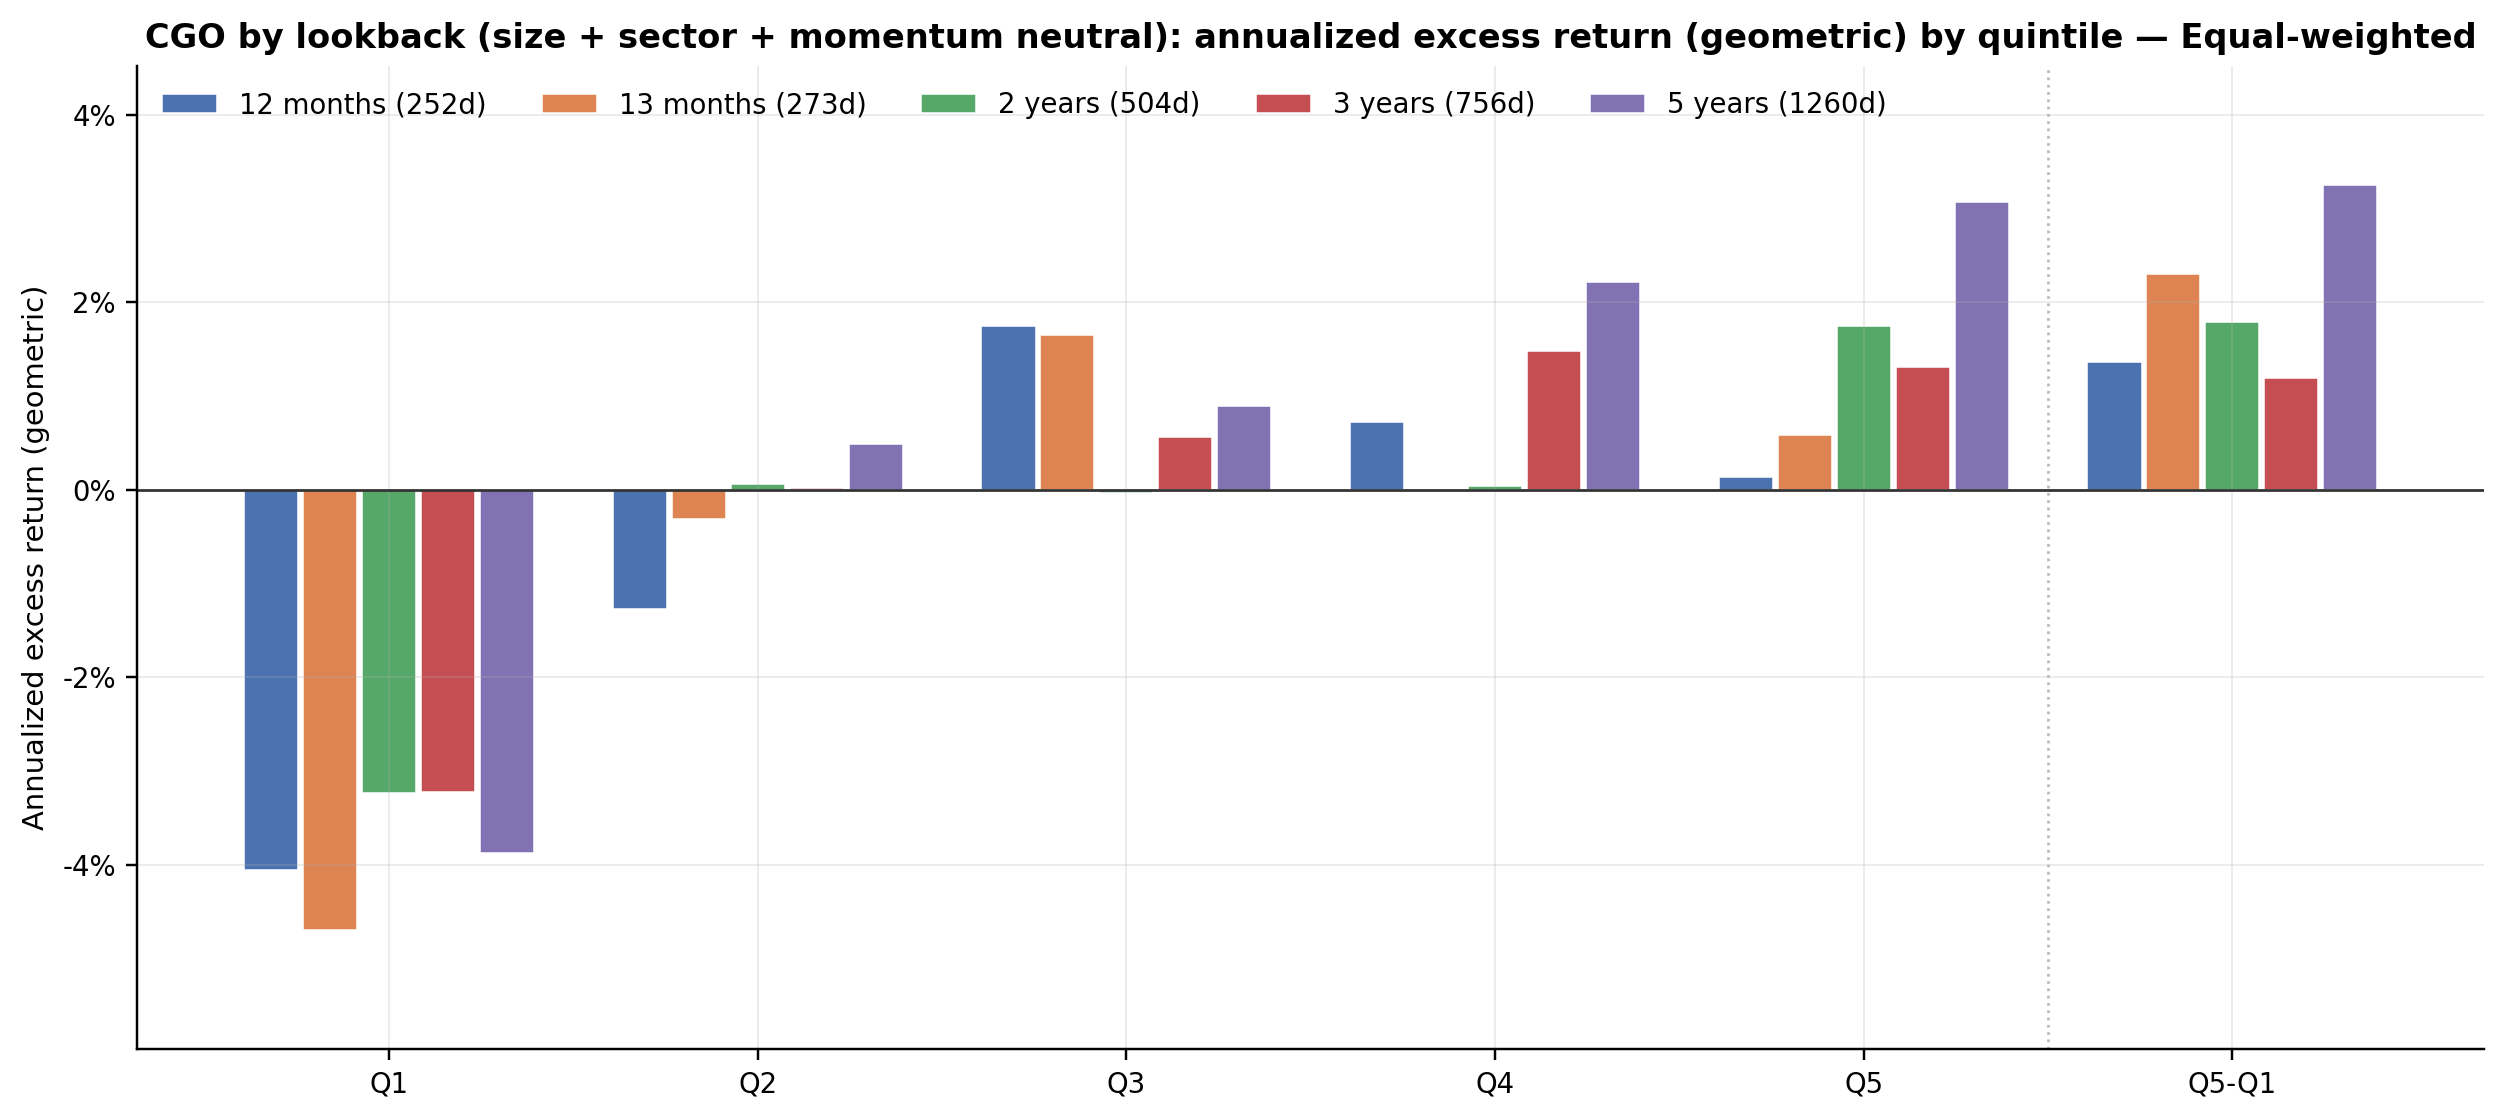

In [8]:
fig = fl.plotting.plot_variant_quantile_bar(sum_mn, q=Q,
    factor="CGO by lookback (size + sector + momentum neutral)",
    weighting=WEIGHTING, labels=HLABELS)
fl.plotting.savefig(fig, f"{FIGDIR}/72_quantile_bar_mom_neutral");

## 5. IC 比較

In [9]:
ics_raw = {c: fl.ic.information_coefficient(panel, f"{c}_blom", "fwd_rtn") for c in HORIZONS}
ics_mn = {c: fl.ic.information_coefficient(panel, f"{c}_blom_mn", "fwd_rtn") for c in HORIZONS}

tbl = pd.concat({
    "raw": pd.DataFrame({HLABELS[c]: fl.ic.ic_summary(ics_raw[c]) for c in HORIZONS}).T,
    "mom_neutral": pd.DataFrame({HLABELS[c]: fl.ic.ic_summary(ics_mn[c]) for c in HORIZONS}).T,
}, names=["variant", "horizon"])
tbl[["mean_IC", "ICIR_ann", "t_stat_NW", "hit_ratio"]]

mean_IC  ICIR_ann  t_stat_NW  hit_ratio
variant     horizon                                                  
raw         12 months (252d)    0.050     0.968      4.614      0.631
            13 months (273d)    0.052     0.987      4.682      0.635
            2 years (504d)      0.053     0.970      4.434      0.626
            3 years (756d)      0.053     0.931      4.202      0.626
            5 years (1260d)     0.054     0.917      4.211      0.631
mom_neutral 12 months (252d)    0.003     0.100      0.459      0.550
            13 months (273d)    0.004     0.131      0.598      0.554
            2 years (504d)      0.009     0.277      1.259      0.532
            3 years (756d)      0.014     0.410      1.882      0.541
            5 years (1260d)     0.022     0.598      2.819      0.563

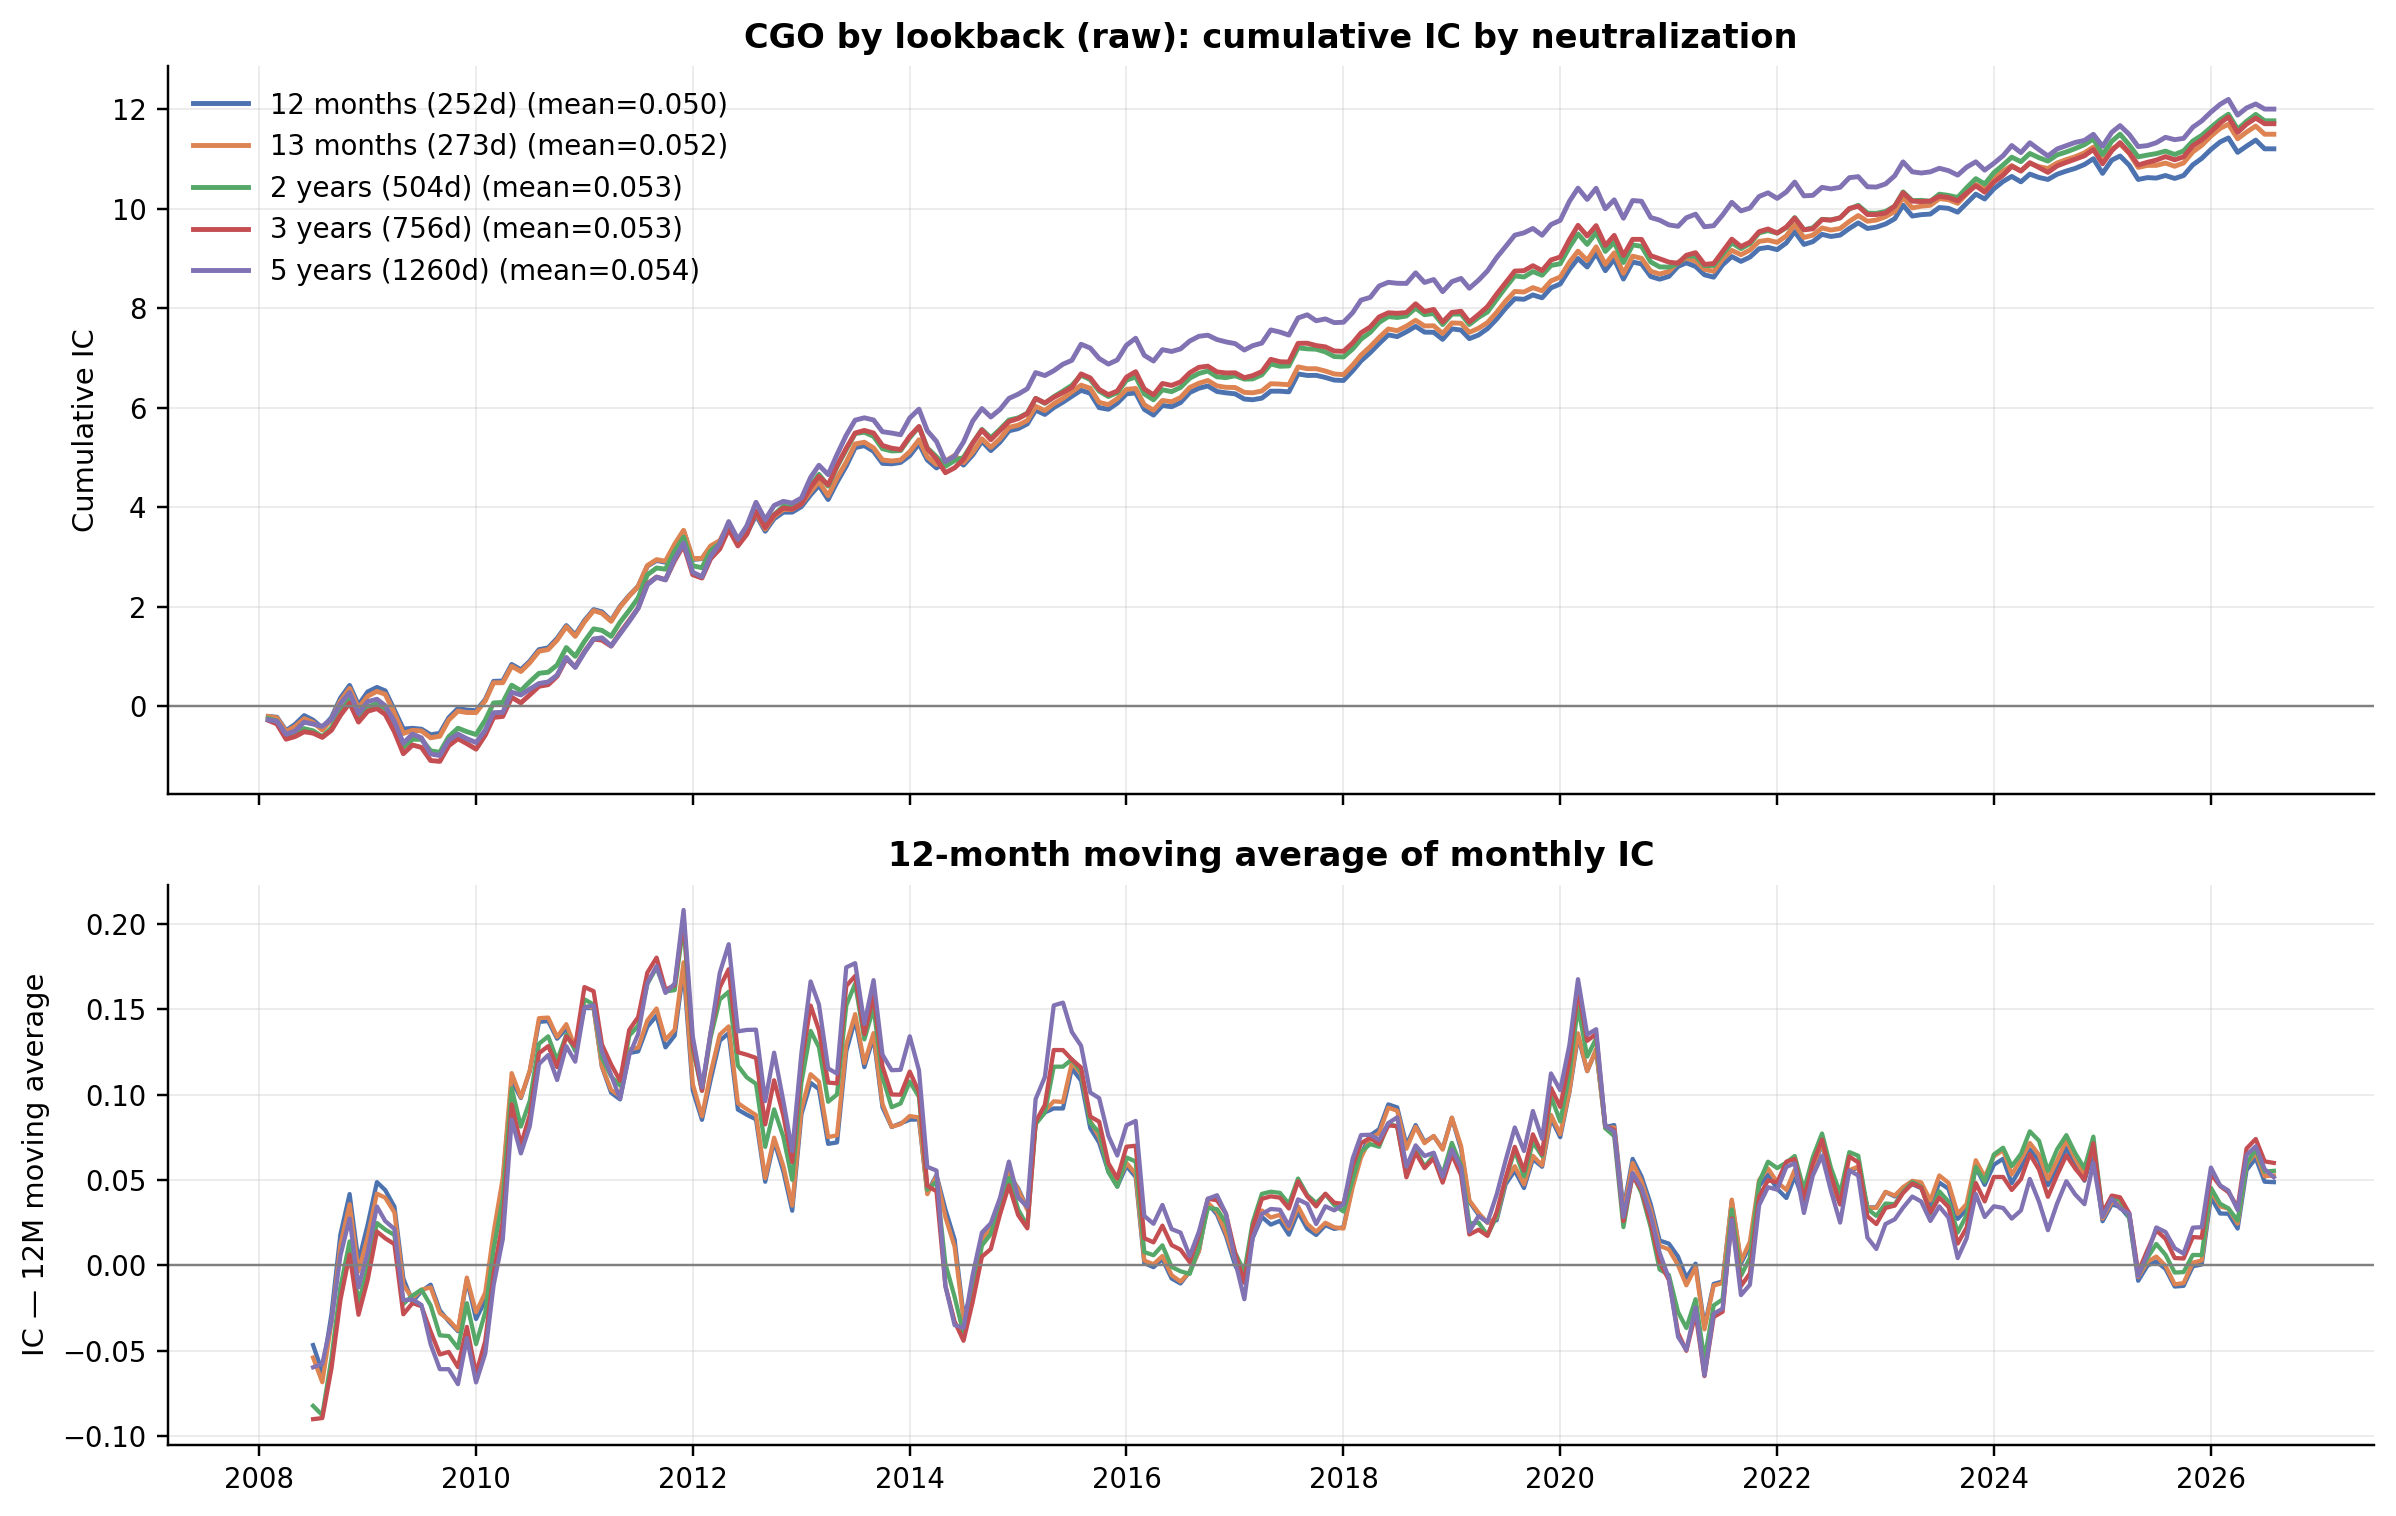

In [10]:
fig = fl.plotting.plot_cumulative_ic_compare(ics_raw, factor="CGO by lookback (raw)", labels=HLABELS)
fl.plotting.savefig(fig, f"{FIGDIR}/73_cumulative_ic_raw");

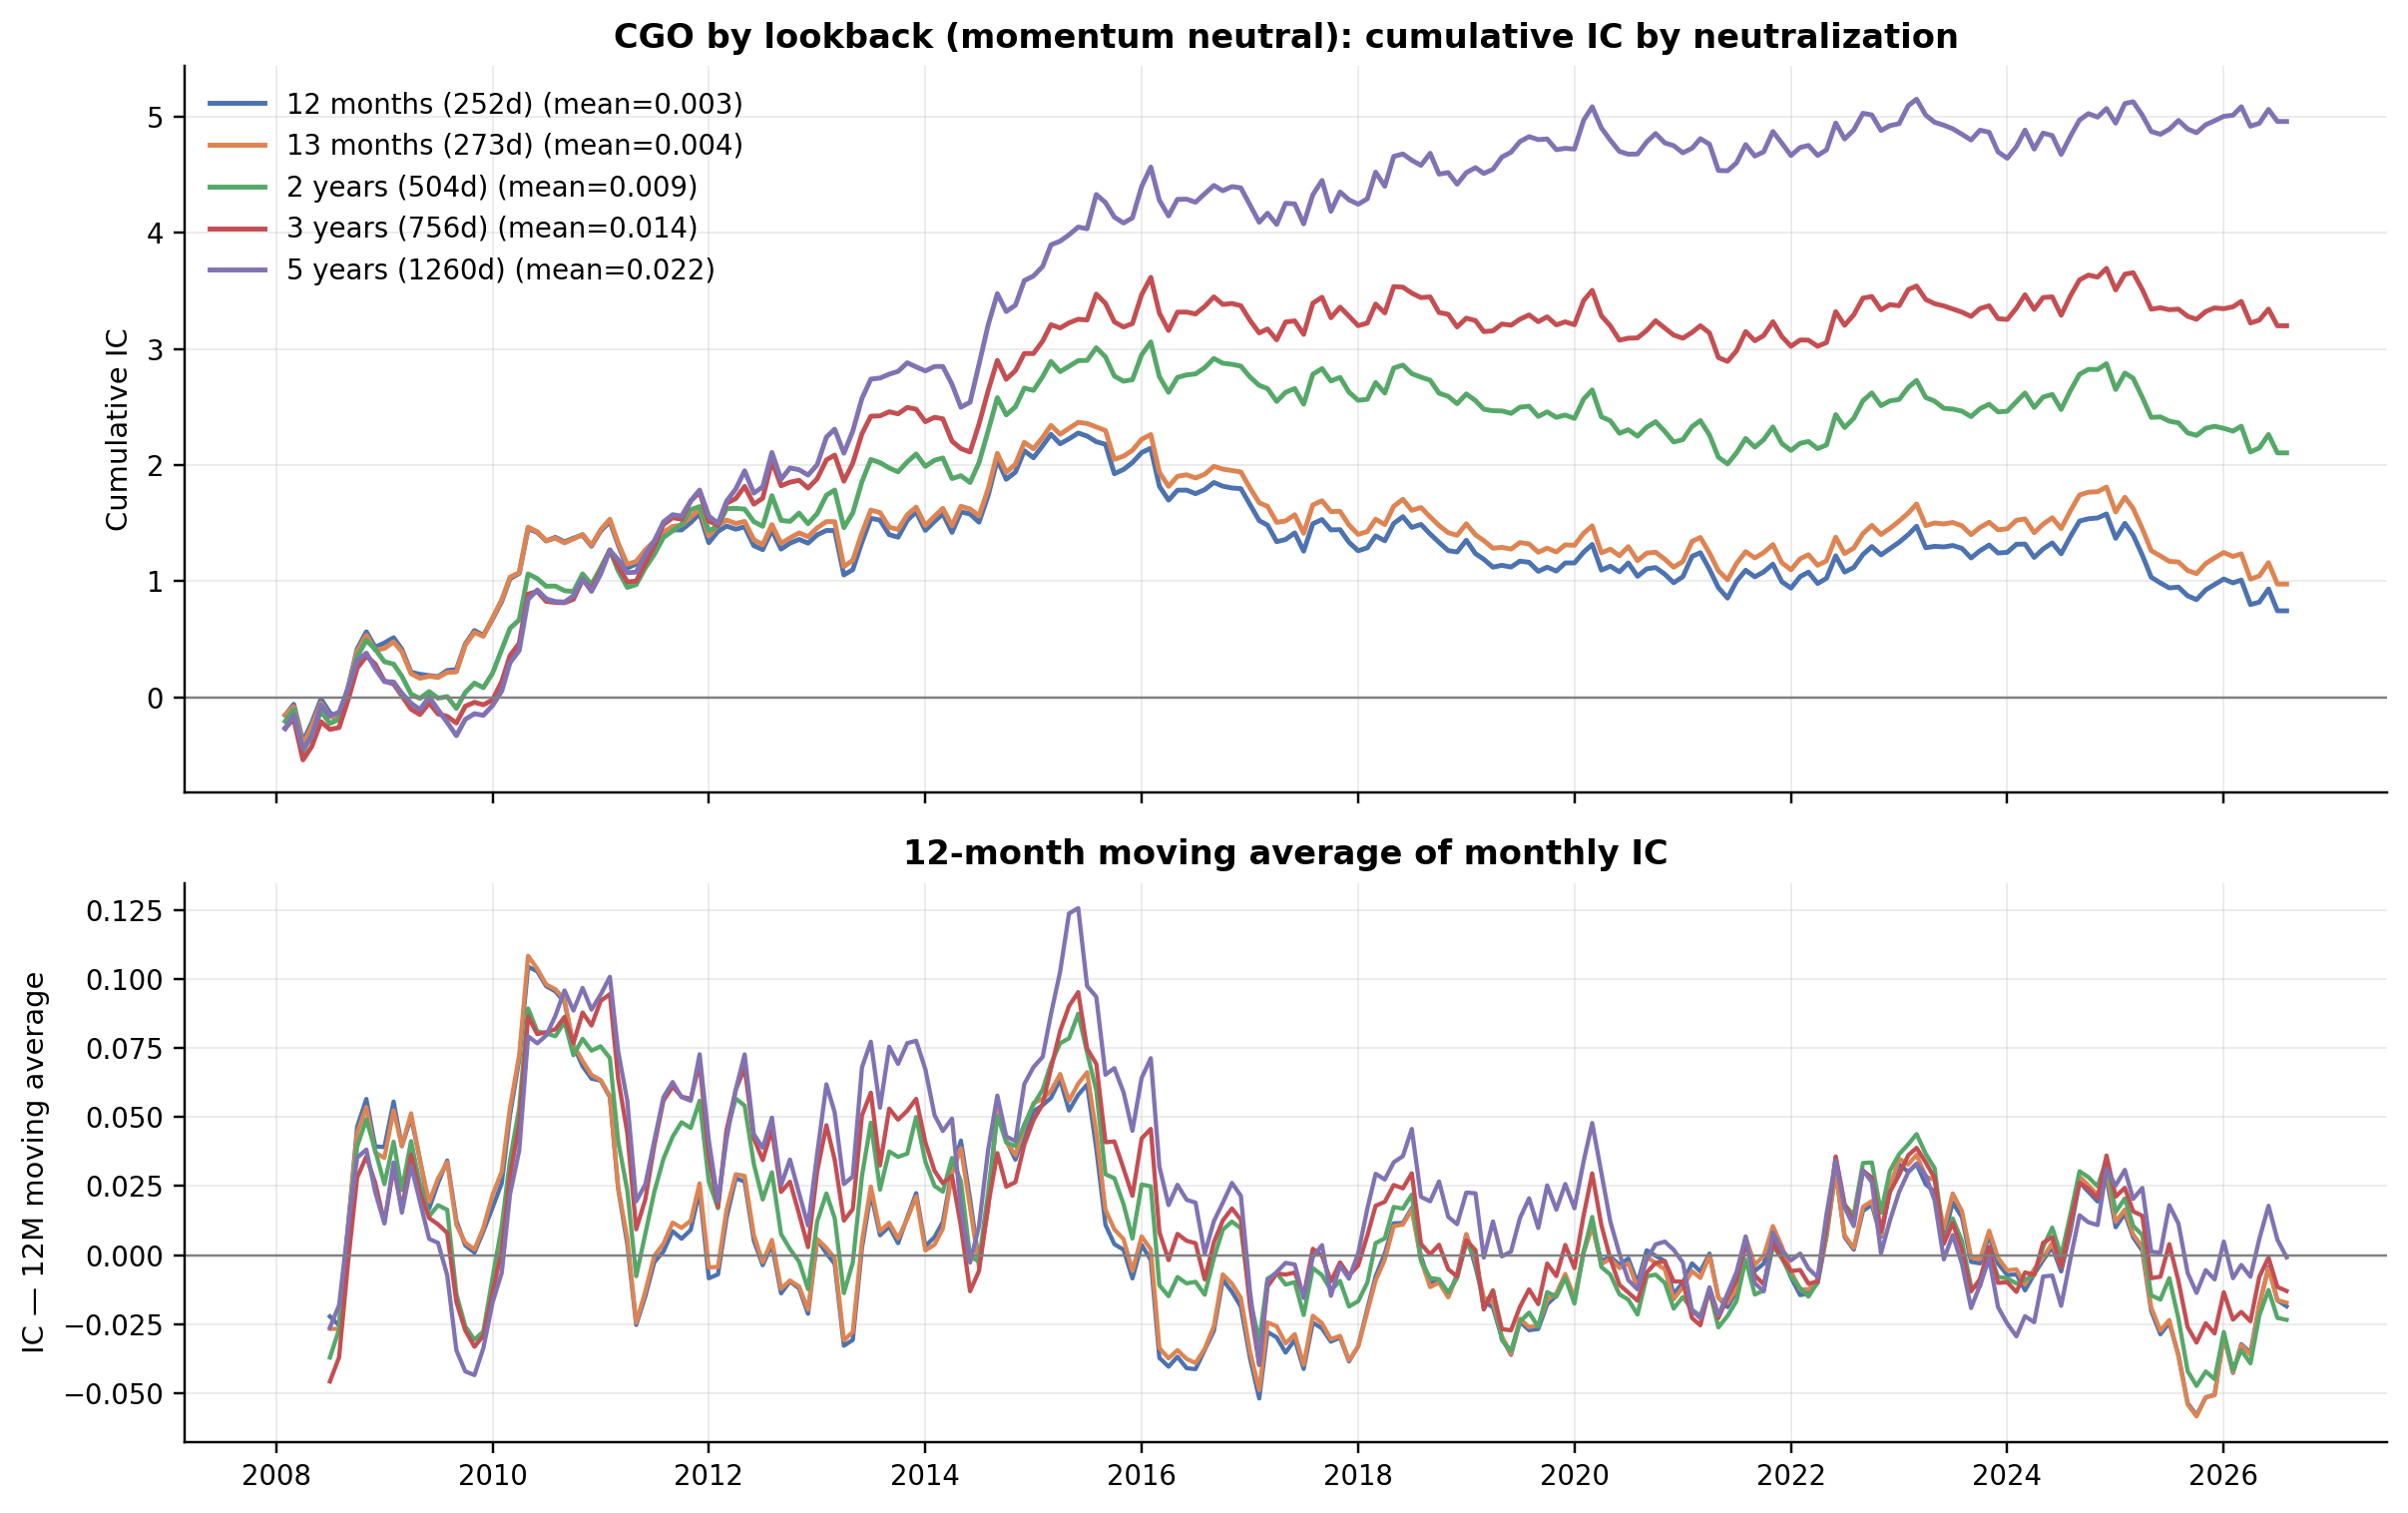

In [11]:
fig = fl.plotting.plot_cumulative_ic_compare(ics_mn, factor="CGO by lookback (momentum neutral)",
                                             labels=HLABELS)
fl.plotting.savefig(fig, f"{FIGDIR}/74_cumulative_ic_mom_neutral");

## 6. 税制変更（2024年7月）前後のサブ期間

サンプルは短い（変更後 ~2年）ので参考値。

In [12]:
def sub_ic(ics, cutoff=202407):
    rows = {}
    for c, ic in ics.items():
        pre = ic[ic.index < cutoff]
        post = ic[ic.index >= cutoff]
        rows[HLABELS[c]] = {
            "IC_pre": pre.mean(), "t_pre": fl.metrics.newey_west_tstat(pre),
            "IC_post": post.mean(), "t_post": fl.metrics.newey_west_tstat(post),
            "n_post": post.notna().sum(),
        }
    return pd.DataFrame(rows).T


print("=== raw ==="); display(sub_ic(ics_raw))
print("=== momentum neutral ==="); display(sub_ic(ics_mn))

=== raw ===


,IC_pre,t_pre,IC_post,t_post,n_post
12 months (252d),0.053,4.585,0.026,0.896,24.000
13 months (273d),0.055,4.619,0.029,0.996,24.000
2 years (504d),0.055,4.262,0.034,1.285,24.000
3 years (756d),0.054,3.950,0.041,1.548,24.000
5 years (1260d),0.056,3.970,0.039,1.464,24.000


=== momentum neutral ===


,IC_pre,t_pre,IC_post,t_post,n_post
12 months (252d),0.006,0.824,-0.020,-0.911,24.000
13 months (273d),0.007,0.967,-0.020,-0.873,24.000
2 years (504d),0.013,1.573,-0.016,-0.769,24.000
3 years (756d),0.017,2.007,-0.004,-0.205,24.000
5 years (1260d),0.024,2.704,0.012,0.684,24.000


---

## 読みどころ

1. **ホライズン間の相関**: 12m と 13m はほぼ同一のはず（1ヶ月分の差）。
   12m と 5y の差が「短期株主 vs 長期株主の含み損益の乖離」
2. raw ではどのホライズンも効くはず（モメンタム込みのため）。
   **momentum 中立後にどこが残るか**が増分情報の所在
3. 税制の仮説どおりなら、12m 近辺のホライズンに固有の情報が出る
   （壁の手前の含み益 = 売り遅延 → リターン持続）